# 02 - Face Detection + Recognition + Person Tracking (Cascade)

**Chay local bang VS Code, dung mo hinh da chot:**
1. **YOLOv8 + ByteTrack** - phat hien & theo doi TOAN BO nguoi trong khung hinh (khong phu thuoc mat co nhin thay hay khong)
2. **insightface (buffalo_l)** - chay TREN TUNG CROP nguoi de phat hien mat + trich embedding ArcFace trong 1 lan goi (bat mat nho/o xa tot hon quet ca khung hinh)
3. So khop embedding voi **gallery** (xay tu `ai/data/splits/gallery` cua Notebook 01) -> known / unknown

**Yeu cau truoc khi chay:** da chay xong Notebook 01 (co du lieu trong `ai/data/splits/gallery` va `ai/data/splits/probe`).

In [1]:
# ===== CELL 1: Thiet lap duong dan =====
import os

BASE_DIR = r'D:\face-security-system'
AI_DIR = os.path.join(BASE_DIR, 'ai')

SPLIT_GALLERY = os.path.join(AI_DIR, 'dataset', 'splits', 'gallery')
SPLIT_PROBE   = os.path.join(AI_DIR, 'dataset', 'splits', 'probe')
MODELS_DIR    = os.path.join(AI_DIR, 'models')
CASCADE_OUT_DIR = os.path.join(AI_DIR, 'dataset', 'cascade_test_output')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(CASCADE_OUT_DIR, exist_ok=True)

print("AI_DIR        =", AI_DIR)
print("SPLIT_GALLERY =", SPLIT_GALLERY)
print("SPLIT_PROBE   =", SPLIT_PROBE)
print("MODELS_DIR    =", MODELS_DIR)
print("CASCADE_OUT_DIR =", CASCADE_OUT_DIR)

assert os.path.exists(SPLIT_GALLERY), "Chua thay data/splits/gallery - chay Notebook 01 truoc"
assert os.path.exists(SPLIT_PROBE), "Chua thay data/splits/probe - chay Notebook 01 truoc"


AI_DIR        = D:\face-security-system\ai
SPLIT_GALLERY = D:\face-security-system\ai\dataset\splits\gallery
SPLIT_PROBE   = D:\face-security-system\ai\dataset\splits\probe
MODELS_DIR    = D:\face-security-system\ai\models
CASCADE_OUT_DIR = D:\face-security-system\ai\dataset\cascade_test_output


In [2]:
# ===== CELL 2: Cai dat thu vien (rieng cho notebook nay) =====
# insightface, opencv, numpy, pandas, matplotlib da co tu Notebook 01.
# ultralytics (YOLOv8) va lapx (can cho ByteTrack) la moi, chua chac da cai.
!pip install -q ultralytics lapx

print("Da cai/kiem tra: ultralytics (YOLOv8 + ByteTrack), lapx")


Da cai/kiem tra: ultralytics (YOLOv8 + ByteTrack), lapx



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ===== CELL 3: Import & set seed =====
import json
import pickle
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print(f"Seed = {SEED}")
print("OpenCV version:", cv2.__version__)


Seed = 42
OpenCV version: 5.0.0


## Buoc 1 - Khoi tao insightface (detect + embedding trong 1 lan goi)

Model `buffalo_l` da bao gom san ca detector (SCRFD) va recognition (ArcFace) - goi `face_app.get(img)` tra ve `Face` object co san `.embedding` (512-d), khong can buoc rieng.

Ap dung lai dung cac fix da kiem chung o Notebook 01:
- `det_thresh=0.3` (thay vi mac dinh ~0.5) - anh crop mat/nguoi thuong "sat" hon anh thuong
- Padding quanh anh truoc khi dua vao detector - tranh hien tuong out-of-distribution khi mat/nguoi chiem gan het khung hinh

In [4]:
# ===== CELL 4: Khoi tao FaceAnalysis & ham get_embedding (chay GPU) =====
import os
import cv2
import numpy as np
import onnxruntime as ort
from insightface.app import FaceAnalysis

# Ưu tiên GPU; CPU chỉ là fallback
print("ONNX Runtime version:", ort.__version__)
print("Available providers:", ort.get_available_providers())

if "CUDAExecutionProvider" not in ort.get_available_providers():
    print("WARNING: CUDAExecutionProvider is not available. FaceAnalysis will fall back to CPU.")

face_app = FaceAnalysis(
    name="buffalo_l",
    allowed_modules=["detection", "recognition"],
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
)

# ctx_id=0 => GPU 0
face_app.prepare(ctx_id=0, det_size=(640, 640), det_thresh=0.3)

PAD_RATIO = 0.4  # them vien de tranh out-of-distribution voi anh crop sat


def get_embedding(img_bgr, pad_ratio=PAD_RATIO):
    '''Phat hien khuon mat co score cao nhat trong anh, tra ve (embedding_512d, det_score).
    Tra ve (None, None) neu khong tim thay mat nao.'''
    if img_bgr is None or img_bgr.size == 0:
        return None, None

    h, w = img_bgr.shape[:2]
    pad_h, pad_w = int(h * pad_ratio), int(w * pad_ratio)
    padded = cv2.copyMakeBorder(img_bgr, pad_h, pad_h, pad_w, pad_w, cv2.BORDER_REFLECT)

    faces = face_app.get(padded)
    if not faces:
        return None, None

    best = max(faces, key=lambda f: f.det_score)
    emb = best.embedding.astype(np.float32)
    emb = emb / (np.linalg.norm(emb) + 1e-10)  # L2 normalize thu cong
    return emb, float(best.det_score)

# Kiem tra provider thuc te cua detector
try:
    det_providers = face_app.models["detection"].session.get_providers()
    print("Detection providers:", det_providers)
except Exception as e:
    print("Could not inspect detection providers:", e)

print("Da khoi tao face_app (buffalo_l, GPU preferred) va dinh nghia get_embedding()")


ONNX Runtime version: 1.26.0
Available providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
model ignore: C:\Users\Admin/.insightface\models\buf

## Buoc 2 - Xay Face Gallery tu `data/splits/gallery`

Moi nguoi co the co nhieu anh gallery -> tinh embedding tung anh, lay **trung binh** (mean) roi chuan hoa lai thanh 1 vector dai dien duy nhat cho nguoi do. Cach nay on dinh hon so voi chi dung 1 anh.

In [5]:
# ===== CELL 5: Xay gallery embeddings =====

gallery = {}          # person_name -> normalized mean embedding (512,)
gallery_log_rows = []

for person in sorted(os.listdir(SPLIT_GALLERY)):
    person_dir = os.path.join(SPLIT_GALLERY, person)
    fnames = os.listdir(person_dir)

    embeddings = []
    for fname in fnames:
        img = cv2.imread(os.path.join(person_dir, fname))
        emb, det_score = get_embedding(img)
        if emb is not None:
            embeddings.append(emb)

    if embeddings:
        mean_emb = np.mean(embeddings, axis=0)
        mean_emb = mean_emb / (np.linalg.norm(mean_emb) + 1e-10)
        gallery[person] = mean_emb

    gallery_log_rows.append([person, len(fnames), len(embeddings)])

gallery_log_df = pd.DataFrame(gallery_log_rows, columns=['person', 'total_images', 'embeddings_computed'])
print(gallery_log_df.to_string(index=False))

gallery_log_path = os.path.join(AI_DIR, 'dataset', 'gallery_build_log.csv')
gallery_log_df.to_csv(gallery_log_path, index=False)

print(f"\nGallery hoan tat: {len(gallery)}/{len(gallery_log_df)} nguoi co embedding")
print(f"Log luu tai: {gallery_log_path}")


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


                   person  total_images  embeddings_computed
         Alejandro_Toledo            81                   81
             Alvaro_Uribe            72                   72
          Amelie_Mauresmo            52                   52
             Andre_Agassi            79                   79
           Angelina_Jolie            44                   44
             Ariel_Sharon           171                  171
    Arnold_Schwarzenegger            79                   79
     Atal_Bihari_Vajpayee            45                   45
             Bill_Clinton            45                   45
            Bui_Manh_Khoi            14                   14
             Carlos_Menem            44                   44
             Colin_Powell           505                  505
            David_Beckham            66                   66
          Donald_Rumsfeld           264                  264
         George_Robertson            39                   39
            George_W_Bus

In [6]:
# ===== CELL 6: Luu gallery embeddings ra file (de backend dung lai sau nay) =====

gallery_path = os.path.join(MODELS_DIR, 'gallery_embeddings.pkl')
with open(gallery_path, 'wb') as f:
    pickle.dump(gallery, f)

print(f"Gallery embeddings ({len(gallery)} nguoi) da luu tai: {gallery_path}")


Gallery embeddings (65 nguoi) da luu tai: D:\face-security-system\ai\models\gallery_embeddings.pkl


## Buoc 3 - Ham so khop (cosine similarity) & test nhanh tren Probe set

`match_face()` so khop embedding voi tung nguoi trong gallery bang cosine similarity (vi embedding da duoc L2-normalize, phep nhan vo huong (dot product) chinh la cosine similarity). Neu diem cao nhat >= threshold -> nhan dang duoc; nguoc lai -> "nguoi la".

`threshold=0.35` la gia tri khoi diem hop ly cho ArcFace; se tinh lai chinh xac hon (ROC/FAR/FRR) o Notebook 04.

In [7]:
# ===== CELL 7: Ham so khop gallery =====

def match_face(query_emb, gallery_dict, threshold=0.35):
    """Tra ve (person_name, score) neu >= threshold, nguoc lai (None, best_score) = nguoi la."""
    if not gallery_dict or query_emb is None:
        return None, 0.0

    best_person, best_score = None, -1.0
    for person, gallery_emb in gallery_dict.items():
        score = float(np.dot(query_emb, gallery_emb))
        if score > best_score:
            best_person, best_score = person, score

    if best_score >= threshold:
        return best_person, best_score
    return None, best_score

print("Da dinh nghia match_face()")


Da dinh nghia match_face()


In [8]:
# ===== CELL 8: Test nhanh tren Probe set (sanity check, chua phai danh gia day du) =====

MATCH_THRESHOLD = 0.35
probe_results = []
correct, total = 0, 0

for person in sorted(os.listdir(SPLIT_PROBE)):
    person_dir = os.path.join(SPLIT_PROBE, person)
    for fname in os.listdir(person_dir):
        img = cv2.imread(os.path.join(person_dir, fname))
        emb, det_score = get_embedding(img)

        if emb is None:
            probe_results.append([person, fname, 'no_face_detected', None, False])
            continue

        pred_person, match_score = match_face(emb, gallery, threshold=MATCH_THRESHOLD)
        is_correct = (pred_person == person)
        correct += int(is_correct)
        total += 1
        probe_results.append([person, fname, pred_person or 'unknown', round(match_score, 3), is_correct])

probe_df = pd.DataFrame(probe_results, columns=['true_person', 'filename', 'predicted', 'match_score', 'correct'])
probe_csv_path = os.path.join(AI_DIR, 'dataset', 'probe_match_results.csv')
probe_df.to_csv(probe_csv_path, index=False)

print(f"Probe accuracy (top-1): {correct}/{total} = {(correct/total*100 if total else 0):.1f}%")
print(f"Ket qua chi tiet luu tai: {probe_csv_path}")
probe_df.head(10)


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Probe accuracy (top-1): 3380/3390 = 99.7%
Ket qua chi tiet luu tai: D:\face-security-system\ai\dataset\probe_match_results.csv


,true_person,filename,predicted,match_score,correct
0,Alejandro_Toledo,img_000.jpg,Alejandro_Toledo,0.784,True
1,Alejandro_Toledo,img_004.jpg,Alejandro_Toledo,0.851,True
2,Alejandro_Toledo,img_005.jpg,Alejandro_Toledo,0.843,True
3,Alejandro_Toledo,img_007.jpg,Alejandro_Toledo,0.830,True
4,Alejandro_Toledo,img_010.jpg,Alejandro_Toledo,0.847,True
5,Alejandro_Toledo,img_011.jpg,Alejandro_Toledo,0.764,True
6,Alejandro_Toledo,img_012.jpg,Alejandro_Toledo,0.864,True
7,Alejandro_Toledo,img_014.jpg,Alejandro_Toledo,0.822,True
8,Alejandro_Toledo,img_015.jpg,Alejandro_Toledo,0.729,True
9,Alejandro_Toledo,img_016.jpg,Alejandro_Toledo,0.833,True


In [9]:
failed = probe_df[probe_df['correct'] == False]
print(failed)

            true_person     filename predicted  match_score  correct
472        Colin_Powell  img_228.jpg   unknown        0.308    False
1166      George_W_Bush  img_379.jpg   unknown        0.339    False
1398      George_W_Bush  img_909.jpg   unknown        0.339    False
1459  Gerhard_Schroeder  img_041.jpg   unknown        0.129    False
1760        Hugo_Chavez  img_044.jpg   unknown        0.328    False
1793        Hugo_Chavez  img_115.jpg   unknown        0.328    False
2217    John_Negroponte  img_035.jpg   unknown        0.146    False
2573      Mahmoud_Abbas  img_022.jpg   unknown        0.115    False
3292        Vicente_Fox  img_009.jpg   unknown        0.095    False
3318        Vicente_Fox  img_073.jpg   unknown        0.095    False


In [10]:
PROCESSED_DIR = os.path.join(AI_DIR, 'dataset', 'processed', 'gallery')
enrolled_people = set(gallery.keys())

stranger_results = []
for person in sorted(os.listdir(PROCESSED_DIR)):
    if person in enrolled_people:
        continue  # đã enroll thì không tính là người lạ

    person_dir = os.path.join(PROCESSED_DIR, person)
    if not os.path.isdir(person_dir):
        continue

    for fname in os.listdir(person_dir):
        img_path = os.path.join(person_dir, fname)
        img = cv2.imread(img_path)
        emb, _ = get_embedding(img)
        if emb is None:
            continue

        pred_person, score = match_face(emb, gallery, threshold=MATCH_THRESHOLD)
        stranger_results.append([person, fname, pred_person, score])

stranger_df = pd.DataFrame(
    stranger_results,
    columns=['nguoi_la_that', 'filename', 'bi_nham_thanh', 'score']
)

false_accepts = stranger_df[stranger_df['bi_nham_thanh'].notna()]

print(f"Tong so anh nguoi la test: {len(stranger_df)}")
print(f"So lan nhan NHAM la nguoi quen (False Accept): {len(false_accepts)}")

if len(stranger_df) == 0:
    print("False Accept Rate uoc tinh: khong tinh duoc vi khong co anh nguoi la hop le.")
else:
    print(f"False Accept Rate uoc tinh: {len(false_accepts)/len(stranger_df)*100:.2f}%")

Tong so anh nguoi la test: 0
So lan nhan NHAM la nguoi quen (False Accept): 0
False Accept Rate uoc tinh: khong tinh duoc vi khong co anh nguoi la hop le.


## Buoc 4 - YOLOv8 (person detection + ByteTrack) + Cascade hoan chinh

`yolov8n.pt` se tu dong tai ve lan dau (~6MB, can internet). Chi lay class `0` = 'person' trong COCO.

**Cascade cho moi frame video:**
1. YOLOv8 + ByteTrack -> bbox + track_id cho TUNG nguoi trong khung hinh
2. Crop vung nguoi -> `get_embedding()` (insightface, co padding) -> tim mat + embedding trong crop do
3. `match_face()` so khop voi gallery -> ve nhan len frame (xanh = biet, do = nguoi la, xam = khong thay mat)
4. Luu video ket qua + log CSV (frame, timestamp, track_id, bbox, ten, diem so) - **log nay se duoc Notebook 03 dung lai** de xay rule-based behavior engine (vung cam / lang vang).

In [11]:
# ===== CELL 9: Tai YOLOv8 (person detector) =====
from ultralytics import YOLO
import torch

print("torch cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    device = 0
else:
    print("WARNING: CUDA not available, YOLO will run on CPU")
    device = "cpu"

person_model = YOLO("yolov8n.pt")
PERSON_CLASS_ID = 0  # 'person' trong COCO

print("Da tai YOLOv8n - se dung de phat hien + theo doi (ByteTrack) class 'person'")


WARNING Ultralytics settings reset to default values. This may be due to a possible problem with your settings or a recent ultralytics package update. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\Admin\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch cuda available: True
gpu: NVIDIA GeForce RTX 5070
Da tai YOLOv8n - se dung de phat hien + theo doi (ByteTrack) class 'person'


In [12]:
# ===== CELL 10: Ham chay cascade tren 1 video =====

def run_cascade_on_video(video_path, gallery_dict, output_video_path,
                          match_threshold=0.35, person_conf=0.4):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise FileNotFoundError(f"Khong mo duoc video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 25
    frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()  # ultralytics se tu mo lai video qua model.track(source=...)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    writer = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_w, frame_h))

    detection_log = []
    frame_idx = 0

    results_gen = person_model.track(
        source=video_path,
        persist=True,
        tracker='bytetrack.yaml',
        classes=[PERSON_CLASS_ID],
        conf=person_conf,
        device=device,
        stream=True,
        verbose=False,
    )

    for r in results_gen:
        frame = r.orig_img.copy()
        boxes = r.boxes
        timestamp_sec = frame_idx / fps

        if boxes is not None and len(boxes) > 0 and boxes.id is not None:
            xyxy = boxes.xyxy.cpu().numpy().astype(int)
            track_ids = boxes.id.cpu().numpy().astype(int)
            confs = boxes.conf.cpu().numpy()

            for (x1, y1, x2, y2), track_id, conf in zip(xyxy, track_ids, confs):
                x1, y1 = max(0, x1), max(0, y1)
                x2, y2 = min(frame_w, x2), min(frame_h, y2)
                person_crop = frame[y1:y2, x1:x2]

                if person_crop.size == 0:
                    continue

                emb, det_score = get_embedding(person_crop)

                if emb is None:
                    label, color = f"ID{track_id} (khong thay mat)", (128, 128, 128)
                    person_name, match_score = None, None
                else:
                    person_name, match_score = match_face(emb, gallery_dict, threshold=match_threshold)
                    if person_name:
                        label = f"ID{track_id} {person_name} ({match_score:.2f})"
                        color = (0, 200, 0)
                    else:
                        label = f"ID{track_id} NGUOI LA ({match_score:.2f})"
                        color = (0, 0, 255)

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
                cv2.putText(frame, label, (x1, max(20, y1 - 8)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

                detection_log.append([
                    frame_idx, round(timestamp_sec, 2), int(track_id),
                    x1, y1, x2, y2,
                    person_name or 'unknown',
                    round(match_score, 3) if match_score is not None else None,
                    round(float(conf), 3),
                ])

        writer.write(frame)
        frame_idx += 1

    writer.release()

    log_df = pd.DataFrame(detection_log, columns=[
        'frame', 'timestamp_sec', 'track_id',
        'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2',
        'matched_person', 'match_score', 'person_conf',
    ])
    log_csv_path = os.path.splitext(output_video_path)[0] + '_detections.csv'
    log_df.to_csv(log_csv_path, index=False)

    print(f"Da xu ly {frame_idx} khung hinh")
    print(f"Video ket qua luu tai: {output_video_path}")
    print(f"Log chi tiet luu tai: {log_csv_path}")
    return log_df

print("Da dinh nghia run_cascade_on_video()")


Da dinh nghia run_cascade_on_video()


d:\face-security-system\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Da xu ly 566 khung hinh
Video ket qua luu tai: D:\face-security-system\ai\dataset\cascade_test_output\annotated_output.mp4
Log chi tiet luu tai: D:\face-security-system\ai\dataset\cascade_test_output\annotated_output_detections.csv
So track_id (nguoi) duy nhat phat hien: 1
So lan gan nhan 'unknown' (nguoi la / khong thay mat): 176


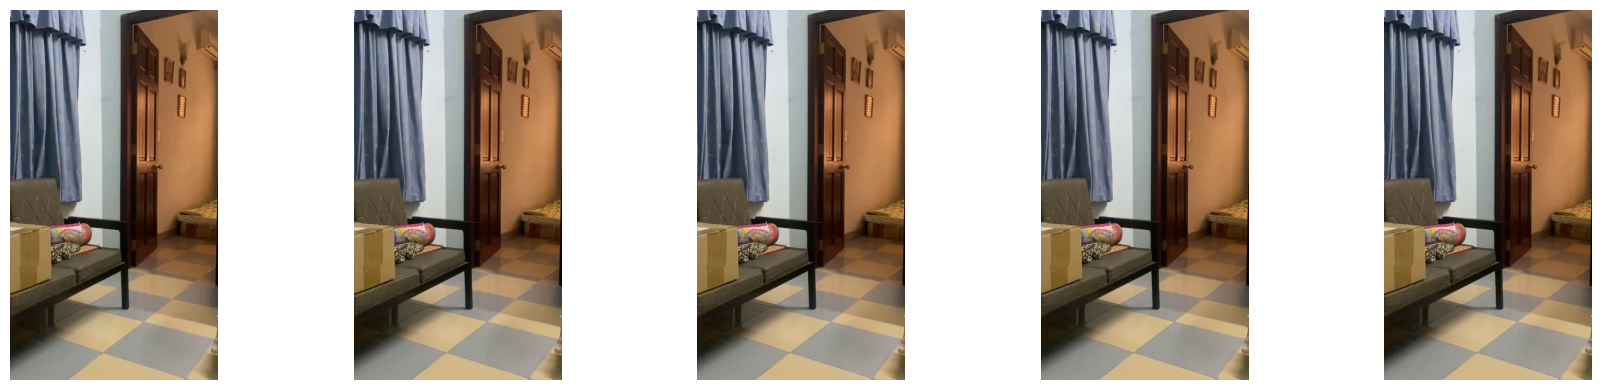

In [13]:
# ===== CELL 11: Chay thu cascade tren video test (doi VIDEO_PATH neu can) =====

VIDEO_PATH = os.path.join(AI_DIR, 'dataset', 'Hai recognition.mp4')
OUTPUT_VIDEO_PATH = os.path.join(CASCADE_OUT_DIR, 'annotated_output.mp4')

if os.path.exists(VIDEO_PATH):
    log_df = run_cascade_on_video(VIDEO_PATH, gallery, OUTPUT_VIDEO_PATH,
                                    match_threshold=MATCH_THRESHOLD, person_conf=0.4)

    n_unique_tracks = log_df['track_id'].nunique() if len(log_df) else 0
    n_unknown = (log_df['matched_person'] == 'unknown').sum() if len(log_df) else 0
    print(f"So track_id (nguoi) duy nhat phat hien: {n_unique_tracks}")
    print(f"So lan gan nhan 'unknown' (nguoi la / khong thay mat): {n_unknown}")

    # Xem thu vai khung hinh dau ra
    cap = cv2.VideoCapture(OUTPUT_VIDEO_PATH)
    sample_frames = []
    for _ in range(5):
        ret, frame = cap.read()
        if not ret:
            break
        sample_frames.append(frame)
    cap.release()

    if sample_frames:
        fig, axes = plt.subplots(1, len(sample_frames), figsize=(18, 4))
        if len(sample_frames) == 1:
            axes = [axes]
        for ax, frame in zip(axes, sample_frames):
            ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            ax.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print(f"Chua tim thay video tai {VIDEO_PATH}")
    print("Quay 1 video co nhieu nguoi, dat vao duong dan tren (hoac doi VIDEO_PATH), roi chay lai cell nay.")


## Tong ket Notebook 02

Ket qua:
- `ai/models/gallery_embeddings.pkl` - gallery embeddings da xay, backend se load lai file nay sau nay
- `ai/data/gallery_build_log.csv` - log so anh/embedding tung nguoi
- `ai/data/probe_match_results.csv` - ket qua sanity-check tren Probe set
- `ai/data/cascade_test_output/annotated_output.mp4` + `annotated_output_detections.csv` - video da ve nhan + log day du (frame, timestamp, track_id, bbox, ten, diem so)

**Buoc tiep theo (Notebook 03):** dung file `annotated_output_detections.csv` (co san track_id + bbox + timestamp theo tung frame) de xay rule-based behavior engine - vung cam (ROI polygon), lang vang (track_id o lau trong 1 vung), nguoi la lap lai nhieu lan.